<a href="https://colab.research.google.com/github/lejonathan24/CSCE676-Project/blob/main/129002924_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CSCE 676 Project**
github link: https://github.com/lejonathan24/CSCE676-Project

# **(A) Identification of Candidate Datasets**

**Candidate Dataset 1**
https://dl.acm.org/doi/10.1145/3336191.3371855
*   Dataset name: market bias
*   Dataset source: https://github.com/MengtingWan/marketBias
*   Course topic alignment: frequent itemsets (sizes), anamoly (rating), clustering (based on sizes, brands)
*   Potential beyond-course techniques: Collaborative Filtering / Matrix Factorization
*   Dataset size and structure: 100 MB, customer rating per row with item information
*   Datatypes: String, int, date & time
*   Target variables: Rating, Gender, Size, Brand
*   Licensing or usage constraints: None

**Candidate Dataset 2**
https://arxiv.org/pdf/2506.13842
*   Dataset name: SatHealth
*   Dataset source: https://github.com/Wang-Yuanlong/SatHealth
*   Course topic alignment: graph analysis (node: regions edges: environmental factors), Clustering
*   Potential beyond-course techniques: Multimodal Deep Learning, Spatial-Temporal Modeling
*   Dataset size and structure: 10 MB, regions and their prevalence of diseases
*   Datatypes: int, string, floats
*   Target variables: prevalence, year, count, patients, location
*   Licensing or usage constraints: None

**Candidate Dataset 3**
https://arxiv.org/abs/2411.05060
*   Dataset name: CDL Misinfo Datasets
*   Dataset source: https://misinfo-datasets.complexdatalab.com/
*   Course topic alignment: graph analysis (sources of misinformation), text mining, anomoly detection
*   Potential beyond-course techniques: Multimodal text + image models, explainable fact-checking AI
*   Dataset size and structure: 1.59GB
*   Datatypes: string, int, date, float
*   Target variables: veracity, binary labels, social engagement labels
*   Licensing or usage constraints: None



# **(B) Comparative Analysis of Datasets**


### Dataset Comparison Table

| **Dimension** | **Market Bias** | **SatHealth** | **CDL Misinfo** |
|---|---|---|---|
| **Supported data mining tasks** | **Course-aligned:**<br>• Frequent itemsets (sizes, brands)<br>• Basic anomaly detection (outlier ratings)<br>• Clustering (customers by size/brand preferences)<br><br>**Beyond-course:**<br>• Collaborative filtering<br>• Matrix factorization for recommendations | **Course-aligned:**<br>• Graph analysis (regions as nodes, environmental factors as edges)<br>• Clustering (regions by disease prevalence patterns)<br><br>**Beyond-course:**<br>• Spatial–temporal modeling<br>• Multimodal deep learning combining satellite + health data | **Course-aligned:**<br>• Graph analysis (information propagation networks)<br>• Text mining (basic NLP features)<br>• Anomaly detection (sudden spikes in engagement or claims)<br><br>**Beyond-course:**<br>• Multimodal text–image models<br>• Explainable misinformation detection |
| **Data quality issues** | • Missing or inconsistent size labels<br>• Subjective and noisy ratings<br>• Self-reported demographic attributes (gender, size) may be inaccurate | • Missing values across regions or years<br>• Measurement noise in satellite-derived features<br>• Spatial and temporal sparsity in some locations | • Noisy and informal text (slang, sarcasm, multilingual content)<br>• Incomplete metadata for posts or sources<br>• Highly imbalanced labels (misinformation vs. non-misinformation) |
| **Algorithmic feasibility** | • Apriori / FP-Growth feasible<br>• Clustering and anomaly detection easily runnable on a single machine<br>• No distributed computing required | • Classical graph algorithms feasible only after preprocessing / aggregation<br>• Full dataset (≈10 GB) may exceed single-machine memory limits<br>• Spark or cloud computing likely needed for scalable graph or temporal models | • Text mining and graph construction feasible on a high-memory workstation<br>• Large-scale graph analytics may be computationally expensive<br>• Deep multimodal models require GPUs and substantial preprocessing |
| **Bias considerations** | • Recommendation bias favoring popular sizes or brands<br>• Underrepresentation of certain body types or genders<br>• Ratings influenced by social norms rather than product quality | • Geographic and reporting bias (wealthier regions better represented)<br>• Disease prevalence influenced by access to healthcare and diagnostics<br>• Satellite data may reflect proxies rather than direct health outcomes | • Platform and sampling bias (data dominated by certain platforms or languages)<br>• Engagement bias amplifying sensational misinformation<br>• Annotation bias in veracity labels |
| **Ethical considerations** | • Reinforcing harmful body image norms through size-based analysis<br>• Risk of discriminatory recommendations if demographic attributes are misused | • Potential stigmatization of regions with high disease prevalence<br>• Risk of misinterpretation leading to flawed policy conclusions<br>• Health data, even aggregated, requires careful framing | • Risk of censorship or mislabeling legitimate discourse as misinformation<br>• Power imbalance between platforms, fact-checkers, and users<br>• Potential misuse for surveillance or political suppression |
| **Other (practical / pedagogical)** | • Very strong fit for course scope and timeline<br>• Easy to explain and visualize results<br>• Ideal for demonstrating classical data mining concepts | • Highly realistic and impactful dataset<br>• Strong research relevance but steep engineering overhead<br>• May distract from core course objectives | • Interdisciplinary and societally relevant<br>• Conceptually rich but technically complex<br>• Requires careful scoping to remain manageable |

---


# **(C) Dataset Selection**

Based on the comparison analysis, I've decided to pursue the Market Bias dataset.

### Reasons for Selection
- The dataset aligns strongly with **core course topics**, including frequent itemset mining, clustering, and anomaly detection, allowing direct application of techniques covered in class.
- Its **moderate size (~100 MB)** makes it computationally feasible to run classical algorithms such as Apriori or FP-Growth on a single machine without requiring distributed systems.
- The structured retail format (ratings, sizes, brands, demographics) enables **clear interpretation and visualization** of results.
- The dataset naturally supports **bias analysis**, particularly around size availability, brand representation, and rating behavior, which strengthens the analytical depth of the project.

### Tradeoffs
- The dataset lacks rich temporal or network structure, limiting advanced graph-based or sequential pattern analysis.
- High-cardinality attributes (e.g., product or user IDs) must be carefully constrained to avoid combinatorial explosion in frequent itemset mining.
- Ethical insights are more subtle compared to health or misinformation datasets and require deliberate framing to avoid superficial conclusions.
- While advanced recommendation techniques (e.g., matrix factorization) are possible, they fall partially outside the course scope and must be used selectively.

Overall, the Market Bias Dataset provides the best balance between **technical feasibility**, **course relevance**, and **meaningful analytical outcomes**, making it an appropriate and manageable choice for this project.



# **(D) Exploratory Data Analysis (Selected Dataset Only)**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Load datasets
electronics_path = "/content/drive/MyDrive/CSCE676 Project Data/df_electronics.csv"
modcloth_path = "/content/drive/MyDrive/CSCE676 Project Data/df_modcloth.csv"

df_elec = pd.read_csv(electronics_path)
df_mod = pd.read_csv(modcloth_path)

print("Electronics shape:", df_elec.shape)
print("ModCloth shape:", df_mod.shape)

df_mod["timestamp"] = pd.to_datetime(df_mod["timestamp"], errors="coerce")


Electronics shape: (1292954, 10)
ModCloth shape: (99893, 12)


In [26]:
df_elec.info()
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1292954 entries, 0 to 1292953
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   item_id     1292954 non-null  int64  
 1   user_id     1292954 non-null  int64  
 2   rating      1292954 non-null  float64
 3   timestamp   1292954 non-null  object 
 4   model_attr  1292954 non-null  object 
 5   category    1292954 non-null  object 
 6   brand       331120 non-null   object 
 7   year        1292954 non-null  int64  
 8   user_attr   174124 non-null   object 
 9   split       1292954 non-null  int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 98.6+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99893 entries, 0 to 99892
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   item_id     99893 non-null  int64              
 1   user_id     99892 non-null  object 

In [27]:
def missing_summary(df):
    return (
        df.isna()
        .mean()
        .sort_values(ascending=False)
        .to_frame("missing_fraction")
    )

missing_summary(df_elec).head(10)

,missing_fraction
user_attr,0.865329
brand,0.743904
user_id,0.000000
item_id,0.000000
rating,0.000000
timestamp,0.000000
category,0.000000
model_attr,0.000000
year,0.000000
split,0.000000


In [28]:
missing_summary(df_mod).head(10)

,missing_fraction
brand,0.740592
size,0.217833
fit,0.185258
timestamp,0.120379
user_attr,0.083760
user_id,0.000010
rating,0.000000
item_id,0.000000
model_attr,0.000000
category,0.000000


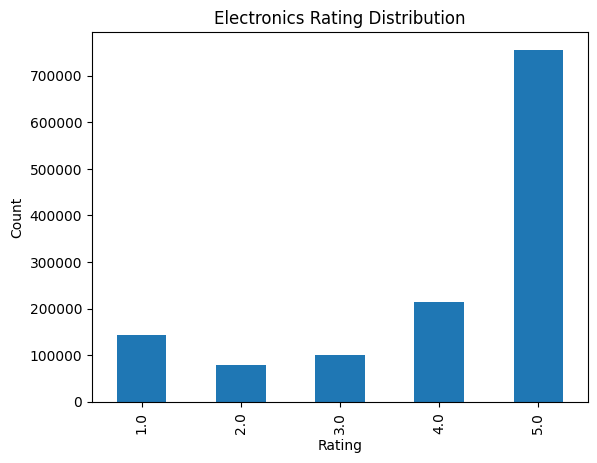

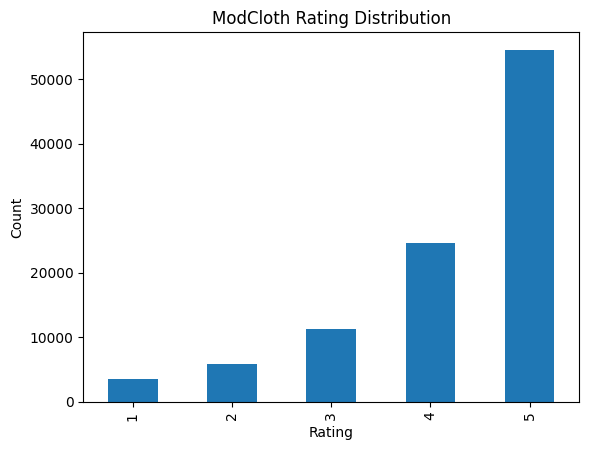

In [29]:
plt.figure()
df_elec["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Electronics Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

plt.figure()
df_mod["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("ModCloth Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [30]:
df_elec["category"].value_counts().head(10)


,count
category,
Headphones,359334
Computers & Accessories,322938
Camera & Photo,192573
Accessories & Supplies,158598
Portable Audio & Video,143370
Car Electronics & GPS,33070
Television & Video,32057
Home Audio,24193
Wearable Technology,16015


In [31]:
df_elec["brand"].value_counts().head(10)



,count
brand,
Bose,29222
Logitech,29203
Sony,20360
Mpow,17477
EldHus,16530
Sennheiser,13322
Fujifilm,12245
TaoTronics,12125
Etre Jeune,11753


In [32]:
df_mod["category"].value_counts().head(10)


,count
category,
Tops,34977
Dresses,34160
Bottoms,23625
Outerwear,7131


In [33]:
df_mod["size"].value_counts().head(10)


,count
size,
2.0,18211
3.0,17752
1.0,15195
5.0,7759
4.0,7388
6.0,6004
7.0,3793
8.0,1948
0.0,83


count    1.157633e+06
mean     1.116895e+00
std      4.713194e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      4.100000e+01
Name: item_id, dtype: float64
count    44783.000000
mean         2.230579
std          6.548969
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        250.000000
Name: item_id, dtype: float64


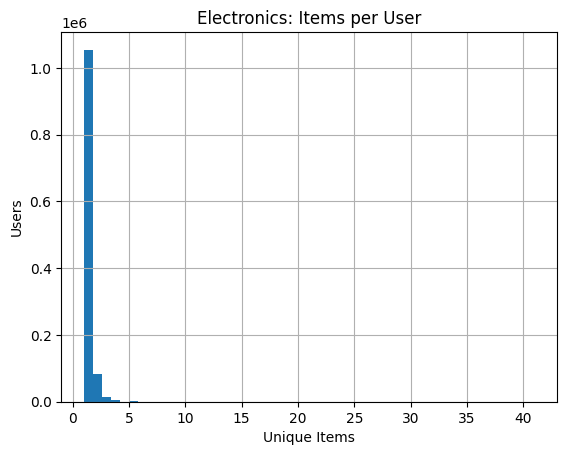

In [34]:
elec_items_per_user = df_elec.groupby("user_id")["item_id"].nunique()
mod_items_per_user = df_mod.groupby("user_id")["item_id"].nunique()

print(elec_items_per_user.describe())
print(mod_items_per_user.describe())
plt.figure()
elec_items_per_user.hist(bins=50)
plt.title("Electronics: Items per User")
plt.xlabel("Unique Items")
plt.ylabel("Users")
plt.show()


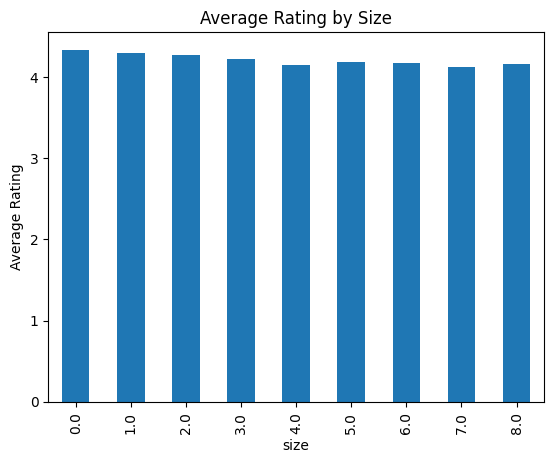

In [35]:
df_mod.groupby("size")["rating"].mean().sort_values()
plt.figure()
df_mod.groupby("size")["rating"].mean().plot(kind="bar")
plt.title("Average Rating by Size")
plt.ylabel("Average Rating")
plt.show()


In [36]:
sample = df_mod.sample(n=5000, random_state=42)

pivot = pd.pivot_table(
    sample,
    index="user_id",
    columns="item_id",
    values="rating",
    aggfunc="count",
    fill_value=0
)

sparsity = 1.0 - (pivot.astype(bool).sum().sum() / pivot.size)
print("Approximate sparsity:", sparsity)

Approximate sparsity: 0.9979828282200718


In [37]:
df_mod["timestamp"] = pd.to_datetime(df_mod["timestamp"])
df_mod = df_mod.sort_values(["user_id", "timestamp"])

df_mod["time_diff_days"] = (
    df_mod.groupby("user_id")["timestamp"]
    .diff()
    .dt.days
)

df_mod["time_diff_days"].describe()



,time_diff_days
count,46492.000000
mean,120.162243
std,235.963190
min,0.000000
25%,0.000000
50%,21.000000
75%,120.000000
max,2588.000000


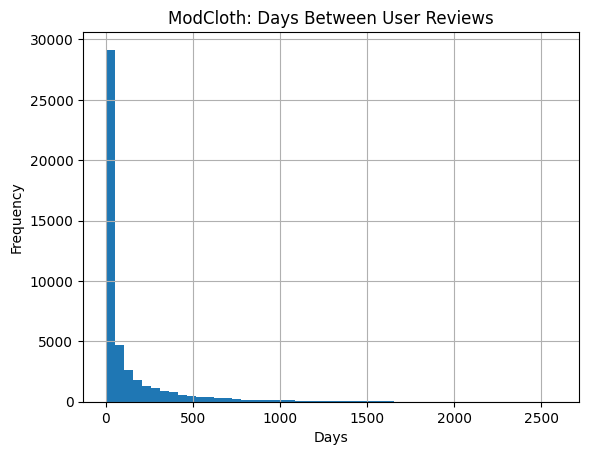

In [38]:
plt.figure()
df_mod["time_diff_days"].dropna().hist(bins=50)
plt.title("ModCloth: Days Between User Reviews")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

In [39]:
df_elec["model_attr"].value_counts().head(10)


,count
model_attr,
Female,481171
Male,429715
Female&Male,382068


<Axes: title={'center': 'Top model_attr Frequencies'}, xlabel='model_attr'>

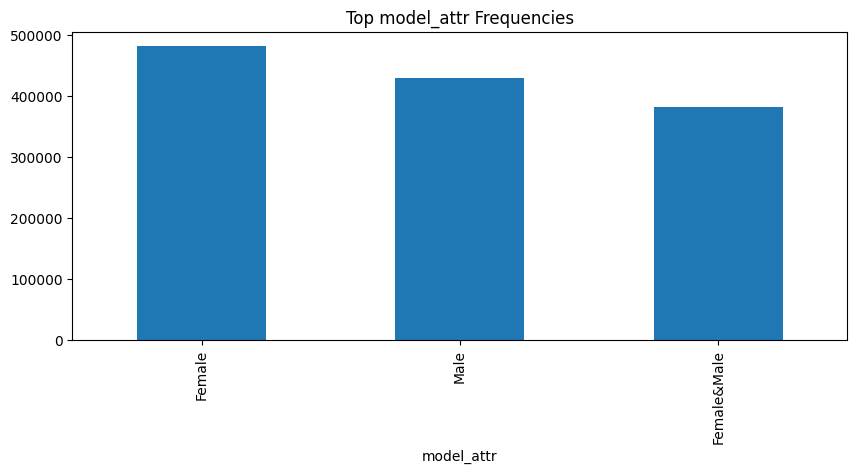

In [40]:
df_elec["model_attr"].value_counts().head(15).plot(
    kind="bar",
    figsize=(10,4),
    title="Top model_attr Frequencies"
)


In [41]:
missing_summary(df_elec)

,missing_fraction
user_attr,0.865329
brand,0.743904
user_id,0.000000
item_id,0.000000
rating,0.000000
timestamp,0.000000
category,0.000000
model_attr,0.000000
year,0.000000
split,0.000000


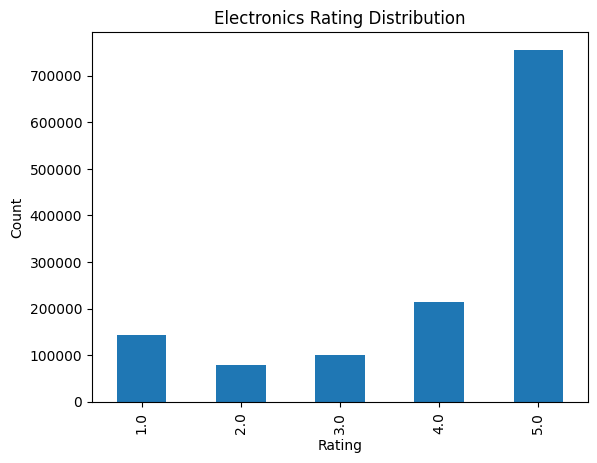

In [43]:
plt.figure()
df_elec["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Electronics Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

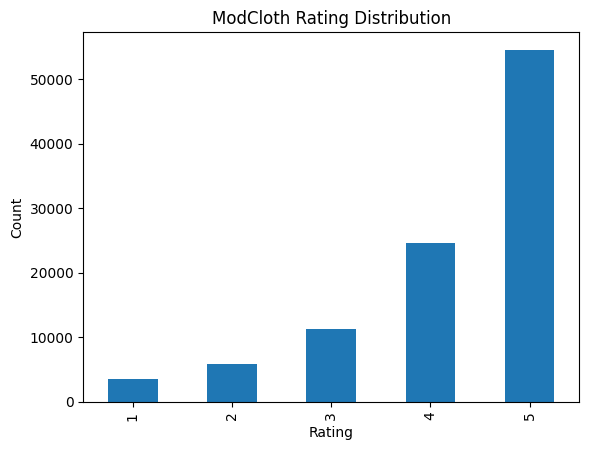

In [45]:
plt.figure()
df_mod["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("ModCloth Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

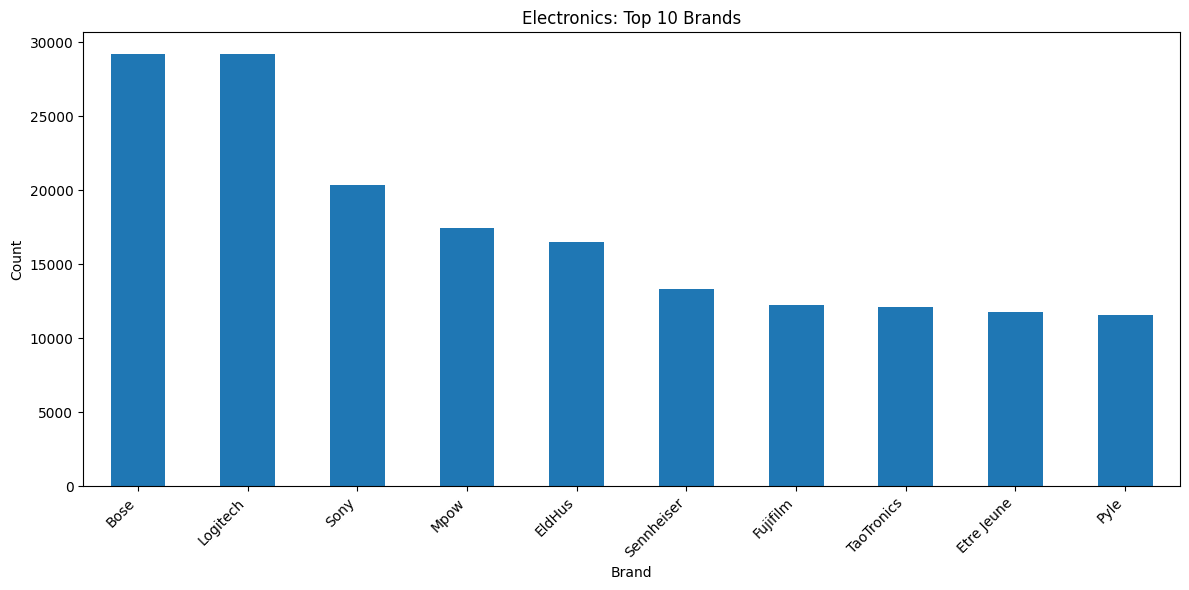

In [48]:
plt.figure(figsize=(12, 6))
df_elec["brand"].value_counts().head(10).plot(kind="bar")
plt.title("Electronics: Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

,rating
model_attr,
Female&Male,4.084244
Female,4.066153
Male,4.005925


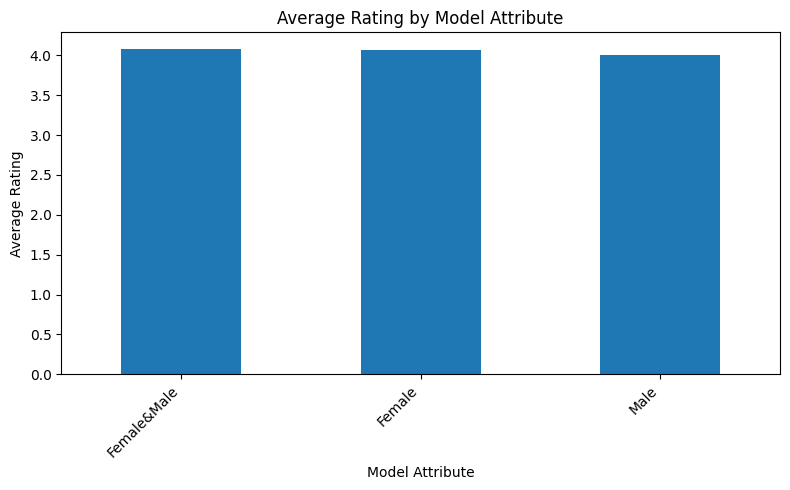

In [50]:
avg_rating_by_model_attr = df_elec.groupby('model_attr')['rating'].mean().sort_values(ascending=False)
display(avg_rating_by_model_attr)

plt.figure(figsize=(8, 5))
avg_rating_by_model_attr.plot(kind='bar')
plt.title('Average Rating by Model Attribute')
plt.xlabel('Model Attribute')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **(E) Initial Insights and Direction**

### Summary of Electronics Data Observations (`df_elec`)

**1. Missing Data:**
*   The `df_elec` DataFrame has significant missing values in `user_attr` (86.5%) and `brand` (74.4%). These columns might require careful handling or imputation if they are central to further analysis.

**2. Rating Distribution:**
*   The ratings are heavily skewed towards higher values, with 5-star ratings being the most frequent, followed by 4-star ratings. Lower ratings (1, 2, 3 stars) are relatively rare, indicating a general positive sentiment among reviewers for electronics products.

**3. Top Categories:**
*   The most prevalent categories in the electronics dataset are 'Headphones', 'Computers & Accessories', and 'Camera & Photo', which together account for a large portion of the reviews.

**4. Top Brands:**
*   'Bose', 'Logitech', and 'Sony' are among the most frequently reviewed brands. The brand distribution shows a clear dominance of a few major players.

**5. Model Attribute and Ratings:**
*   The `model_attr` column primarily consists of 'Female', 'Male', and 'Female&Male'.
*   While all average ratings are high (above 4.0), there's a subtle difference: 'Female&Male' models have the highest average rating (4.08), followed by 'Female' (4.06), and then 'Male' (4.005). These differences are small but suggest potential slight variations in how different model attributes are perceived or rated.

**6. Items per User:**
*   The `elec_items_per_user` analysis shows that most users in the `df_elec` dataset have reviewed only one item. The mean is approximately 1.12 items per user, with a maximum of 41 items reviewed by a single user. This indicates a high proportion of one-time reviewers and suggests that collaborative filtering approaches based on extensive user history might be challenging due to data sparsity.

## ModCloth Data Observations Summary

Based on the Exploratory Data Analysis (EDA) of the `df_mod` DataFrame, here are the key observations:

### 1. Missing Data

The `df_mod` DataFrame exhibits several columns with significant missing values:
*   `brand`: Approximately 74.06% of values are missing, indicating that brand information is largely unavailable for ModCloth items.
*   `size`: About 21.78% of values are missing, suggesting that size information is not always recorded or applicable.
*   `fit`: Approximately 18.53% of values are missing, similar to size, indicating incomplete fit descriptions.
*   `timestamp`: Around 12.04% of timestamps are missing, which could impact time-series analysis.
*   `user_attr`: About 8.38% of user attributes are missing.

### 2. Rating Distribution

The ModCloth rating distribution (ratings from 1 to 5) is heavily skewed towards higher ratings. Ratings of 5 are the most frequent, followed by 4. Ratings of 1, 2, and 3 are comparatively rare, indicating a general tendency for users to provide positive feedback.

### 3. Top Product Categories

The top product categories in the ModCloth dataset are:
1.  Tops (34977 entries)
2.  Dresses (34160 entries)
3.  Bottoms (23625 entries)
4.  Outerwear (7131 entries)

### 4. Most Common Sizes

The most commonly reviewed sizes in the ModCloth dataset are:
1.  2.0 (18211 entries)
2.  3.0 (17752 entries)
3.  1.0 (15195 entries)
4.  5.0 (7759 entries)
5.  4.0 (7388 entries)

### 5. Items per User

For the ModCloth dataset, the `mod_items_per_user` statistics show that:
*   The average user reviews about 2.23 unique items.
*   The median is 1, and the 75th percentile is 2, meaning a large proportion of users review only one or two items.
*   The maximum number of items reviewed by a single user is 250.
*   The histogram shows a very sharp peak at 1, indicating that the vast majority of users have reviewed only a single item, with a long tail extending to users who have reviewed many items.

### 6. Data Sparsity

The approximate sparsity of the user-item interaction matrix for `df_mod` is 0.99798, or nearly 99.8%. This extremely high sparsity indicates that very few possible user-item pairs actually have a recorded interaction (rating). This makes direct item-item co-occurrence or collaborative filtering challenging and suggests a need for attribute-level analysis or dimensionality reduction techniques.

### 7. Average Rating by Size

While overall ratings are high, average ratings show some variation across sizes. For instance, size 0.0 has the lowest average rating, followed by 8.0, 7.0, and 6.0. Sizes 1.0, 2.0, 3.0, 4.0, and 5.0 tend to have higher average ratings. Although the differences in average ratings are numerically small (e.g., from 3.7 to 4.2), they are consistent across sizes and suggest potential size- or fit-related biases.

### 8. Time Differences Between User Reviews

The descriptive statistics for `time_diff_days` (days between consecutive reviews by the same user) show:
*   The mean time difference is approximately 120 days (about 4 months).
*   The median is 21 days (about 3 weeks).
*   A significant portion of reviews (25th percentile) are posted on the same day (0 days difference).
*   The maximum difference is 2588 days (over 7 years).
*   The histogram reveals a sharp peak at 0 days, indicating many users post multiple reviews on the same day, followed by a rapid decrease and a long tail, showing that other reviews can be spaced out over very long periods.

### Hypotheses and Research Questions (Integrating both `df_elec` and `df_mod`)

---

New Hypotheses

-   **H1 (Comparative Bias Manifestation):** While both datasets exhibit skewed rating distributions, the nature of market bias will differ; ModCloth will show stronger size- and fit-related biases, whereas Electronics will likely manifest brand- and category-specific biases, possibly influenced by `model_attr`.
-   **H2 (Impact of Missing Attributes):** The high percentage of missing `brand` data in both `df_elec` and `df_mod`, and `size`/`fit` in `df_mod`, is not random and may correlate with item characteristics or user types, thus impacting the representativeness of frequent itemset mining and subsequent bias detection.
-   **H3 (Temporal Influence on Bias):** For products with longer lifecycles or fashion trends (e.g., ModCloth items), temporal analysis will reveal evolving biases or changes in rating patterns over time, which might be less pronounced in rapidly evolving electronics markets.
-   **H4 (User Behavior & Sparsity):** The observed extreme sparsity in user-item interactions across both datasets (most users review very few items) suggests that a significant portion of users are single-purchase or single-review customers, making user-based collaborative filtering challenging without rich attribute data or external information.

---

### New Potential Research Questions (RQs)

-   **RQ1 (Cross-Domain Bias Comparison):** How do the statistical characteristics and implications of size-based biases in apparel (`df_mod`) compare to those of model-attribute or brand-based biases in electronics (`df_elec`)? Are there common underlying mechanisms for these biases?
-   **RQ2 (Enriching Sparse Data):** Can advanced imputation techniques or external data sources effectively mitigate the impact of high missing values (e.g., `brand`, `user_attr`, `size`, `fit`) to uncover more comprehensive market patterns and biases in both datasets?
-   **RQ3 (Attribute Interaction and Rating):** How do interactions between different product attributes (e.g., `category` and `brand` in `df_elec`, or `size` and `fit` in `df_mod`) collectively influence customer ratings, and can these interactions reveal specific niches of market dissatisfaction or satisfaction?
-   **RQ4 (Temporal Pattern Discovery):** Can sequential pattern mining on user review histories (using `timestamp`) in the ModCloth dataset reveal evolving user preferences or early indicators of product dissatisfaction that are not evident from static rating distributions?
-   **RQ5 (Hybrid Approaches for Sparsity):** Given the high sparsity, can a hybrid approach combining attribute-based frequent itemset mining with model-based collaborative filtering (e.g., using item embeddings derived from attributes) more effectively identify and potentially mitigate market biases than either method alone?

# **On my honor, I declare the following resources:**
1. Collaborators:
-

2. Web Sources:
- Homework 1 & 2 for EDA inspiration
- https://www.icwsm.org/2025/schedule/allpapers.html
- https://kdd2025.kdd.org/datasets-and-benchmarks-track-papers-2/


3. AI Tools:
- chatGPT: Used to compare the three datasets for the Comparative Analysis of Datasets
- chatGPT: Used to help generate a EDA
- chatGPT: Provided with EDA results and asked to give observations, hypothesis, and potential RQs
